In [1]:
import sys
sys.path.append("..")  # so we can import from src/

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller

from src.data_loader import load_combined

sns.set_style("darkgrid")
plt.rcParams["figure.figsize"] = (12, 5)

df = load_combined()
df.head()

,Adj Close,Close,High,Low,Open,Volume,Ticker
Date,,,,,,,
2015-01-02,14.620667,14.620667,14.883333,14.217333,14.858000,71466000,TSLA
2015-01-05,14.006000,14.006000,14.433333,13.810667,14.303333,80527500,TSLA
2015-01-06,14.085333,14.085333,14.280000,13.614000,14.004000,93928500,TSLA
2015-01-07,14.063333,14.063333,14.318667,13.985333,14.223333,44526000,TSLA
2015-01-08,14.041333,14.041333,14.253333,14.000667,14.187333,51637500,TSLA


In [2]:
print(df.shape)
print(df.dtypes)
print(df["Ticker"].value_counts())
df.describe()

(8664, 7)
Adj Close    float64
Close        float64
High         float64
Low          float64
Open         float64
Volume         int64
Ticker           str
dtype: object
Ticker
TSLA    2888
BND     2888
SPY     2888
Name: count, dtype: int64


,Adj Close,Close,High,Low,Open,Volume
count,8664.000000,8664.000000,8664.000000,8664.000000,8664.000000,8.664000e+03
mean,188.927213,201.106120,202.866633,199.191505,201.092515,6.631883e+07
std,169.807691,171.936619,173.233832,170.501862,171.925462,6.552771e+07
min,9.578000,9.578000,10.331333,9.403333,9.488000,0.000000e+00
25%,62.670265,74.070000,74.207499,73.927500,74.059998,6.247225e+06
50%,133.437668,133.437668,136.053329,125.831669,131.496330,6.165465e+07
75%,279.182503,294.117508,298.355003,291.380005,295.083336,9.453975e+07
max,757.618225,759.570007,760.400024,756.750000,758.150024,9.140820e+08


In [2]:
missing = df.groupby("Ticker").apply(lambda g: g.isnull().sum())
print(missing)

# Reindex each ticker onto a full business-day calendar, then forward-fill
# This handles market holidays that differ slightly between exchanges
dfs = []
for ticker, group in df.groupby("Ticker"):
    full_range = pd.date_range(start=group.index.min(), end=group.index.max(), freq="B")
    g = group.reindex(full_range)
    g["Ticker"] = ticker
    g[["Open", "High", "Low", "Close", "Adj Close", "Volume"]] = g[
        ["Open", "High", "Low", "Close", "Adj Close", "Volume"]
    ].ffill()
    dfs.append(g)

df = pd.concat(dfs)
df.index.name = "Date"
print("After cleaning:", df.isnull().sum().sum(), "missing values remain")

        Adj Close  Close  High  Low  Open  Volume
Ticker                                           
BND             0      0     0    0     0       0
SPY             0      0     0    0     0       0
TSLA            0      0     0    0     0       0
After cleaning: 0 missing values remain


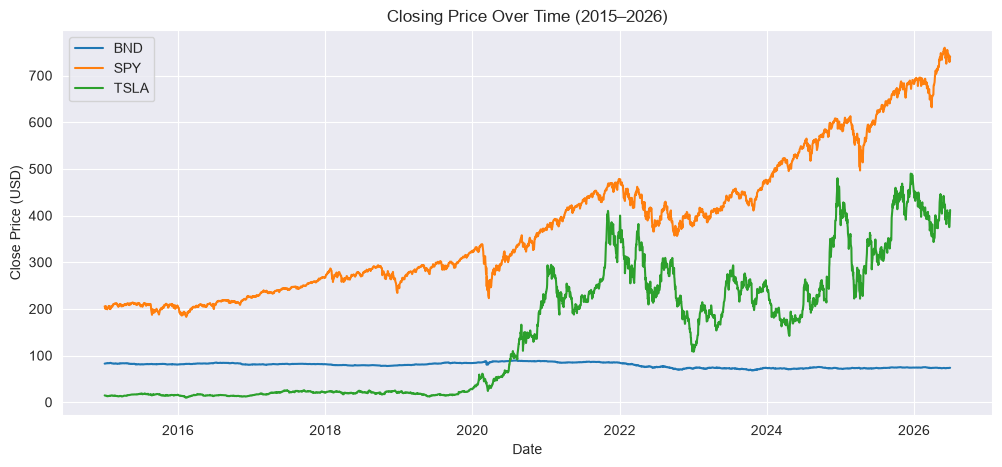

In [3]:
fig, ax = plt.subplots()
for ticker, group in df.groupby("Ticker"):
    ax.plot(group.index, group["Close"], label=ticker)
ax.set_title("Closing Price Over Time (2015–2026)")
ax.set_xlabel("Date")
ax.set_ylabel("Close Price (USD)")
ax.legend()
plt.show()

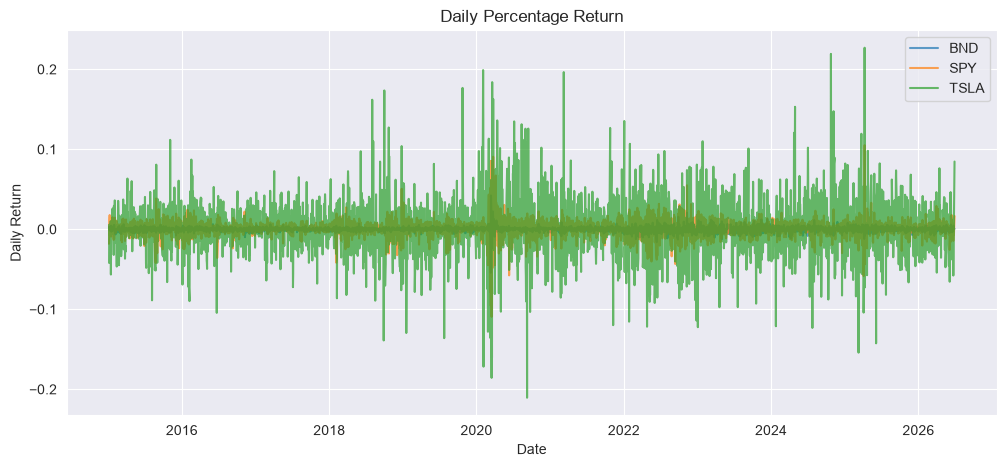

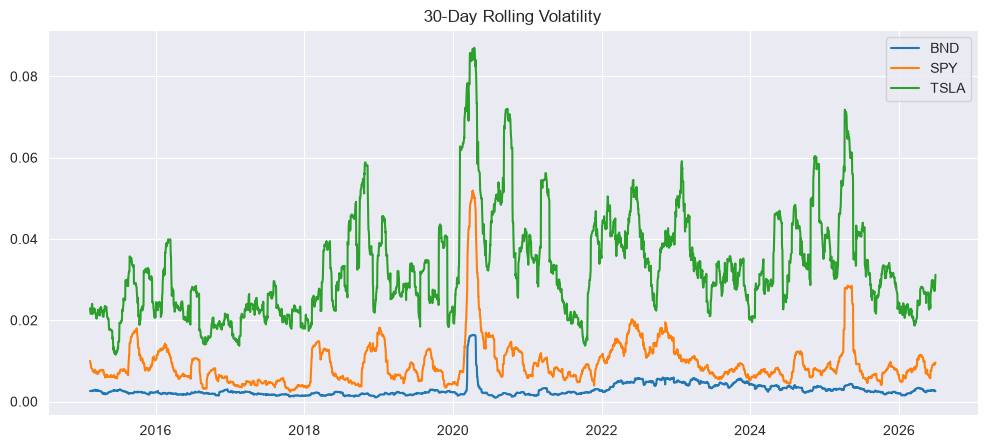

In [4]:
df["Daily Return"] = df.groupby("Ticker")["Close"].pct_change()

fig, ax = plt.subplots()
for ticker, group in df.groupby("Ticker"):
    ax.plot(group.index, group["Daily Return"], label=ticker, alpha=0.7)
ax.set_title("Daily Percentage Return")
ax.set_xlabel("Date")
ax.set_ylabel("Daily Return")
ax.legend()
plt.show()

# Rolling volatility (30-day standard deviation of returns)
df["Rolling Volatility"] = df.groupby("Ticker")["Daily Return"].transform(
    lambda x: x.rolling(window=30).std()
)

fig, ax = plt.subplots()
for ticker, group in df.groupby("Ticker"):
    ax.plot(group.index, group["Rolling Volatility"], label=ticker)
ax.set_title("30-Day Rolling Volatility")
ax.legend()
plt.show()

TSLA outlier days (>3 std dev): 50
                 Close  Daily Return
Date                                
2020-09-08  110.070000     -0.210628
2020-03-16   29.671333     -0.185778
2020-02-05   48.980000     -0.171758
2020-03-18   24.081333     -0.160344
2025-03-10  222.149994     -0.154262
2025-06-05  284.700012     -0.142599
2018-09-28   17.651333     -0.139015
2019-07-25   15.254667     -0.136137
2020-03-09   40.533333     -0.135725
2019-01-18   20.150667     -0.129711
2020-02-27   45.266666     -0.128146
2024-07-24  215.990005     -0.123346
2023-01-03  108.099998     -0.122422
2022-04-26  292.140015     -0.121841
2024-01-25  182.630005     -0.121253
2021-11-09  341.166656     -0.119903
2020-03-12   37.369999     -0.116172
2022-01-27  276.366669     -0.115542
2022-12-27  109.099998     -0.114089
2022-01-31  312.239990      0.106776
2020-07-10  102.976669      0.107848
2020-09-09  122.093330      0.109233
2023-01-26  160.270004      0.109673
2018-08-07   25.304667      0.109886
202

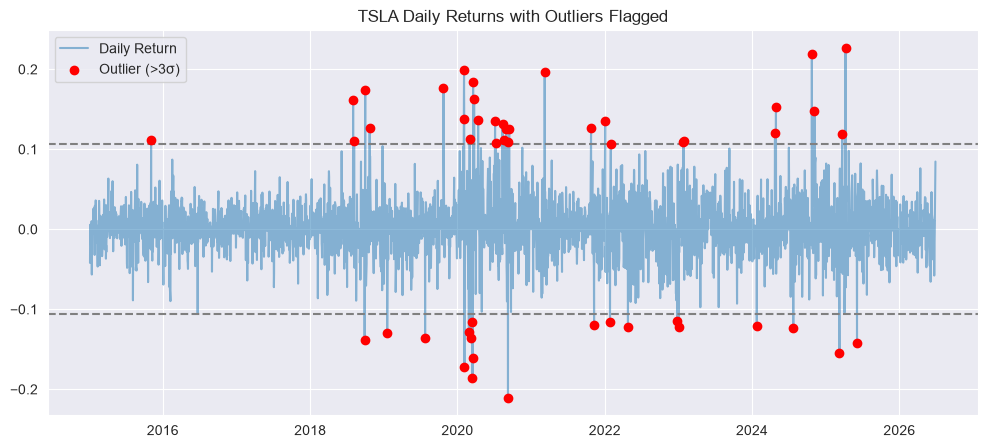

In [5]:
tsla = df[df["Ticker"] == "TSLA"].copy()
threshold = tsla["Daily Return"].std() * 3

outliers = tsla[tsla["Daily Return"].abs() > threshold]
print(f"TSLA outlier days (>3 std dev): {len(outliers)}")
print(outliers[["Close", "Daily Return"]].sort_values("Daily Return"))

fig, ax = plt.subplots()
ax.plot(tsla.index, tsla["Daily Return"], alpha=0.5, label="Daily Return")
ax.scatter(outliers.index, outliers["Daily Return"], color="red", label="Outlier (>3σ)", zorder=5)
ax.axhline(threshold, color="gray", linestyle="--")
ax.axhline(-threshold, color="gray", linestyle="--")
ax.set_title("TSLA Daily Returns with Outliers Flagged")
ax.legend()
plt.show()

In [7]:
def run_adf(series, label):
    result = adfuller(series.dropna())
    print(f"--- ADF Test: {label} ---")
    print(f"ADF Statistic: {result[0]:.4f}")
    print(f"p-value: {result[1]:.4f}")
    print(f"Critical Values: {result[4]}")
    is_stationary = result[1] < 0.05
    print(f"Stationary: {is_stationary}\n")
    return is_stationary

for ticker in ["TSLA", "BND", "SPY"]:
    prices = df[df["Ticker"] == ticker]["Close"]
    returns = df[df["Ticker"] == ticker]["Daily Return"]
    run_adf(prices, f"{ticker} Close Price")
    run_adf(returns, f"{ticker} Daily Return")

--- ADF Test: TSLA Close Price ---
ADF Statistic: -1.0387
p-value: 0.7389
Critical Values: {'1%': np.float64(-3.432555920657187), '5%': np.float64(-2.8625146314725565), '10%': np.float64(-2.5672888226314647)}
Stationary: False

--- ADF Test: TSLA Daily Return ---
ADF Statistic: -55.1498
p-value: 0.0000
Critical Values: {'1%': np.float64(-3.432535279976574), '5%': np.float64(-2.8625055152431513), '10%': np.float64(-2.5672839692475775)}
Stationary: True

--- ADF Test: BND Close Price ---
ADF Statistic: -1.0814
p-value: 0.7224
Critical Values: {'1%': np.float64(-3.4325396703967974), '5%': np.float64(-2.862507454335551), '10%': np.float64(-2.5672850015989264)}
Stationary: False

--- ADF Test: BND Daily Return ---
ADF Statistic: -21.3758
p-value: 0.0000
Critical Values: {'1%': np.float64(-3.4325396703967974), '5%': np.float64(-2.862507454335551), '10%': np.float64(-2.5672850015989264)}
Stationary: True

--- ADF Test: SPY Close Price ---
ADF Statistic: 1.1497
p-value: 0.9956
Critical Values:

In [8]:
risk_summary = {}

for ticker in ["TSLA", "BND", "SPY"]:
    returns = df[df["Ticker"] == ticker]["Daily Return"].dropna()

    # Historical VaR at 95% confidence: the 5th percentile of daily returns
    var_95 = np.percentile(returns, 5)

    # Sharpe Ratio: annualized mean return / annualized std, assuming ~0% risk-free rate
    annual_return = returns.mean() * 252
    annual_vol = returns.std() * np.sqrt(252)
    sharpe = annual_return / annual_vol

    risk_summary[ticker] = {
        "Daily VaR (95%)": var_95,
        "Annualized Return": annual_return,
        "Annualized Volatility": annual_vol,
        "Sharpe Ratio": sharpe,
    }

risk_df = pd.DataFrame(risk_summary).T
risk_df

,Daily VaR (95%),Annualized Return,Annualized Volatility,Sharpe Ratio
TSLA,-0.051096,0.437713,0.561299,0.779821
BND,-0.004950,-0.008237,0.052711,-0.156264
SPY,-0.016529,0.123098,0.173957,0.707635


In [9]:
import os
out_path = os.path.join("..", "data", "processed", "cleaned_combined.csv")
df.to_csv(out_path)
print(f"Cleaned data saved to {out_path}")

Cleaned data saved to ..\data\processed\cleaned_combined.csv
